In [78]:
import cuml
%load_ext cuml.accel

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [79]:
import pandas as pd
import numpy as np
import sklearn

## Feature engineering

In [80]:
train_df = pd.read_csv('./data/train.csv')
test_df = pd.read_csv('./data/test.csv')

In [81]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [82]:
train_df.isna().agg(["sum"])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
sum,0,0,0,0,0,177,0,0,0,0,687,2


In [83]:
test_df.isna().agg(["sum"])

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
sum,0,0,0,0,86,0,0,0,1,327,0


In [84]:
age_median = train_df.groupby(["Pclass", "Sex"])["Age"].agg("median")
fare_median = train_df.groupby(["Pclass", "Sex"])["Fare"].agg("median")

In [86]:
train_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [87]:
from sklearn.preprocessing import OneHotEncoder

def preprocess(df, age_median, fare_median):
    df = df.copy()
    df.drop(["Cabin", "Ticket", "PassengerId"], axis=1, inplace=True)
    df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
    # df["Sex_PClass"] = df["Sex"].astype(str) + "_" + df["Pclass"].astype(str)
    
    # Fill missing values
    # age_mask = df["Age"].isna()
    # df.loc[age_mask, "Age"] = df.loc[age_mask].set_index(["Pclass", "Sex"]).index.map(age_median)
    # fare_mask = df["Fare"].isna()
    # df.loc[fare_mask, "Fare"] = df.loc[fare_mask].set_index(["Pclass", "Sex"]).index.map(fare_median)
    
    
    # Create tuple index for mapping
    idx = pd.MultiIndex.from_arrays([df["Pclass"], df["Sex"]])
    
    # Fill missing values using passed-in medians
    df["Age"] = df["Age"].fillna(pd.Series(idx.map(age_median), index=df.index))
    df["Fare"] = df["Fare"].fillna(pd.Series(idx.map(fare_median), index=df.index))
    # df["AgeBin"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100], labels=["Child", "Teen", "Adult", "Middle", "Senior"])
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df["Title"] = df["Name"].str.extract(r' ([A-Za-z]+)\.')
    main_titles = ['Mr', 'Mrs', 'Miss', 'Master']
    df["Title"] = df["Title"].map(lambda x: x if x in main_titles else "Rare")

    
    df["Title"] = df["Title"].astype("category")
    df["Embarked"] = df["Embarked"].astype("category")
    
    # Drop original columns and concatenate encoded columns
    df = df.drop(['Name'], axis=1)
    
    
    return df

    
    

## Train

In [88]:
# Train XGBoost model (GPU-accelerated via cuML)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
# from cuml.naive_bayes import GaussianNB
import cudf
cleaned_train_df = preprocess(train_df, age_median, fare_median)
X = cleaned_train_df.drop(["Survived"], axis=1)
y = cleaned_train_df["Survived"]

# Convert to cuDF for GPU acceleration
# X_gpu = cudf.DataFrame(X)
# y_gpu = cudf.Series(y)



In [89]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,3,0,22.0,1,0,7.2500,S,Mr
1,1,1,38.0,1,0,71.2833,C,Mrs
2,3,1,26.0,0,0,7.9250,S,Miss
3,1,1,35.0,1,0,53.1000,S,Mrs
4,3,0,35.0,0,0,8.0500,S,Mr


In [108]:
# Split for validation
# X_train, X_val, y_train, y_val = train_test_split(X_gpu, y_gpu, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
hyper_param = {'n_estimators': 120, 'max_depth': 8, 'max_leaves': 24, 'learning_rate': 0.10374448010818738, 'subsample': 0.9062292064783252, 'colsample_bytree': 0.7991232614099266, 'reg_alpha': 1.1317657421008092e-08, 'reg_lambda': 2.9919974380229196e-06, 'min_child_weight': 3}

# Create and train model
# model = XGBClassifier(
#     # n_estimators=100,
#     # max_depth=7,
#     # max_leaves=128,
#     # learning_rate=0.1,
#     **hyper_param,
#     enable_categorical=True,
#     tree_method='hist',
#     device='cuda',
#     random_state=42,
# )


hyper_param = {'max_depth': 12, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': None, 'criterion': 'log_loss', 'splitter': 'best', 'max_leaf_nodes': 59, 'min_impurity_decrease': 0.0017278770327136123}
model = DecisionTreeClassifier(
    **hyper_param,
    random_state=42,
    enable_categorical=True
    )
# model = GaussianNB()
# model = LogisticRegression(max_iter=10000)

model.fit(X_train, y_train)

# Evaluate - convert cuDF to pandas/numpy for sklearn metrics
# print(f"Validation Accuracy: {model.score(X_val.to_pandas(), y_val.to_numpy()):.4f}")

# Get cross-validated predictions
y_pred_cv = cross_val_predict(model, X, y, cv=5)

# Print the classification report
print(classification_report(y, y_pred_cv, digits=4))

TypeError: DecisionTreeClassifier.__init__() got an unexpected keyword argument 'enable_categorical'

<Axes: >

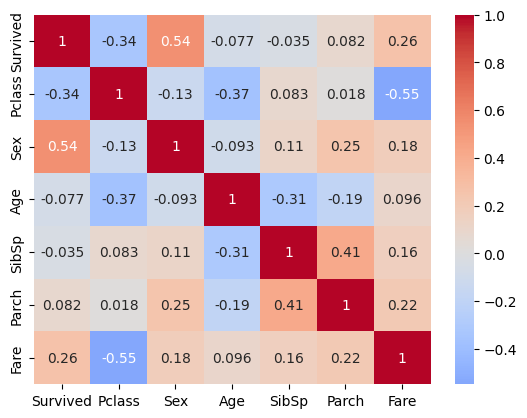

In [105]:
import seaborn as sns

sns.heatmap(cleaned_train_df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)

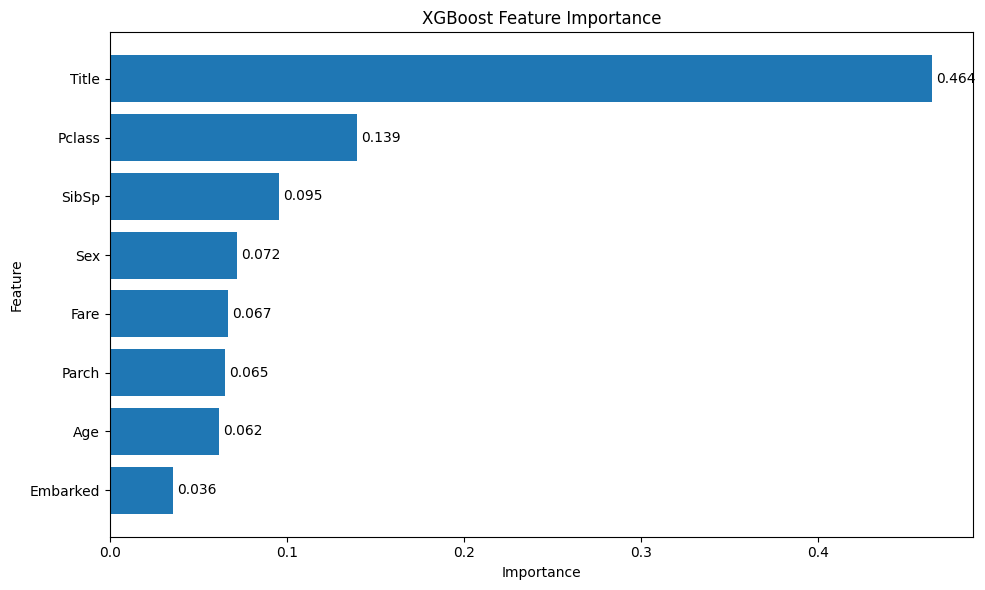

In [91]:
import matplotlib.pyplot as plt

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feature_importance['feature'], feature_importance['importance'])
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [92]:
model.fit(X, y)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7991232614099266
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [93]:
cleaned_test_df = preprocess(test_df, age_median, fare_median)
X_test = cleaned_test_df

y_test = model.predict(X_test)

In [94]:
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": y_test
})

In [95]:
submission.to_csv("./out/submission.csv", index=False)

In [96]:
# submission = pd.read_csv("./out/submit.csv")

In [97]:
def test(submission):
        

    gt = pd.read_csv("./out/gt.csv")

    print((gt == submission).agg("mean"))
test(submission)

PassengerId    1.00000
Survived       0.76555
dtype: float64


In [98]:
# model_name = type(model).__name__
# !kaggle competitions submit -c titanic -f ./out/submission.csv -m "{model_name}"